# GECS Classification — Data Cleaning Pipeline
**DePaul x Morningstar Capstone | Spring 2026**

Covers:
- Task 1: Industry Classification (`task1_gecs_classification_final.csv`, 53,585 records, 145 classes)
- Task 2: Subindustry Classification (`task2_subindustry_classification_final.csv`, 27,537 records, 450 classes)



## 0. Imports & Config

In [4]:
%pip install -q pandas matplotlib seaborn

import re
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
log = logging.getLogger(__name__)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

# ── CONFIG ──────────────────────────────────────────
TASK       = 1          # 1 or 2
INPUT_PATH = f'task{TASK}_gecs_classification_final.csv'
OUTPUT_PATH = INPUT_PATH.replace('.csv', '_cleaned.csv')
# ────────────────────────────────────────────────────

TASK1_REQUIRED = [
    'CompanyId', 'AsOfDate', 'LongProfile',
    'SegmentName', 'SegmentDescription',
    'Revenue', 'total_revenue_company_as_of',
    'revenue_share', 'is_largest_share_segment',
    'MstarGlobal'
]
TASK2_REQUIRED = [
    'CompanyId', 'AsOfDate',
    'SegmentName', 'SegmentDescription',
    'Subindustry'
]
LABEL_COL  = 'MstarGlobal' if TASK == 1 else 'Subindustry'
N_EXPECTED = 145 if TASK == 1 else 450
DATE_RANGE = ('2003-12-31', '2024-12-31') if TASK == 1 else ('2020-05-31', '2024-12-31')

print(f'Task {TASK} | Label: {LABEL_COL} | Expected classes: {N_EXPECTED}')


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Task 1 | Label: MstarGlobal | Expected classes: 145


## 1. Load Data

In [ ]:
df_raw = pd.read_csv('/Users/meetpatel/Documents/capstone/dataset/task1_gecs_classification_final.csv', encoding='utf-8')

print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (53585, 10)


,CompanyId,AsOfDate,LongProfile,SegmentName,SegmentDescription,Revenue,total_revenue_company_as_of,revenue_share,is_largest_share_segment,MstarGlobal
0,AX2S5G3YJ2,2024-12-31,"The company is an American packaged-food manufacturer. It operate in a single industry segment and manufacture, sell...",Frozen & Vegetables,Frozen & Vegetables segment includes the Green Giant and Le Sueur brands.,395785000.0,1.932454e+09,0.204810,False,20525040
1,AX2S5G3YJ2,2024-12-31,"The company is an American packaged-food manufacturer. It operate in a single industry segment and manufacture, sell...",Meals,"Meals segment includes, among others, the Ortega, Maple Grove Farms, Cream of Wheat, Las Palmas, Victoria, Mama Mary...",462397000.0,1.932454e+09,0.239280,False,20525040
2,AX2S5G3YJ2,2024-12-31,"The company is an American packaged-food manufacturer. It operate in a single industry segment and manufacture, sell...",Specialty,"Specialty segment includes, among others, the Crisco, Clabber Girl, Bear Creek, Polaner, Underwood, B&G, Grandma’s, ...",679076000.0,1.932454e+09,0.351406,True,20525040


In [6]:
df_raw.dtypes

CompanyId                          str
AsOfDate                           str
LongProfile                        str
SegmentName                        str
SegmentDescription                 str
Revenue                        float64
total_revenue_company_as_of    float64
revenue_share                  float64
is_largest_share_segment          bool
MstarGlobal                      int64
dtype: object

## 2. Schema Validation

In [7]:
required = TASK1_REQUIRED if TASK == 1 else TASK2_REQUIRED
missing_cols = [c for c in required if c not in df_raw.columns]

if missing_cols:
    raise ValueError(f'Missing expected columns: {missing_cols}')
else:
    print('All required columns present.')

df = df_raw[required].copy()
print(f'Kept {len(required)} columns: {required}')

All required columns present.
Kept 10 columns: ['CompanyId', 'AsOfDate', 'LongProfile', 'SegmentName', 'SegmentDescription', 'Revenue', 'total_revenue_company_as_of', 'revenue_share', 'is_largest_share_segment', 'MstarGlobal']


## 3. Initial Null Audit

                             null_count  null_pct
SegmentDescription                27524     51.37
CompanyId                             0      0.00
AsOfDate                              0      0.00
LongProfile                           0      0.00
SegmentName                           0      0.00
Revenue                               0      0.00
total_revenue_company_as_of           0      0.00
revenue_share                         0      0.00
is_largest_share_segment              0      0.00
MstarGlobal                           0      0.00


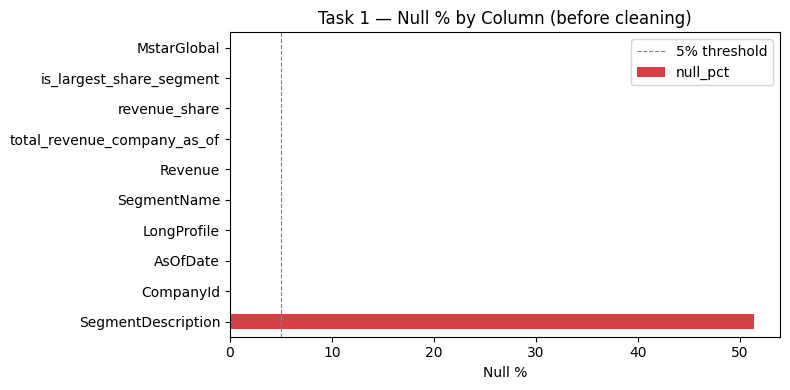

In [8]:
null_summary = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct':   (df.isna().mean() * 100).round(2)
}).sort_values('null_pct', ascending=False)

print(null_summary.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
null_summary['null_pct'].plot(kind='barh', ax=ax, color='#d64045')
ax.set_xlabel('Null %')
ax.set_title(f'Task {TASK} — Null % by Column (before cleaning)')
ax.axvline(5, color='gray', linestyle='--', linewidth=0.8, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Deduplication

In [9]:
dedup_keys = ['CompanyId', 'AsOfDate'] if TASK == 1 else ['CompanyId', 'AsOfDate', 'SegmentName']

before = len(df)
df = df.drop_duplicates(subset=dedup_keys, keep='first')
dropped = before - len(df)

print(f'Rows before : {before:,}')
print(f'Rows after  : {len(df):,}')
print(f'Duplicates  : {dropped:,} ({dropped/before*100:.2f}%)')

Rows before : 53,585
Rows after  : 23,207
Duplicates  : 30,378 (56.69%)


## 5. Date Parsing & Range Filter

In [10]:
df['AsOfDate'] = pd.to_datetime(df['AsOfDate'], errors='coerce')

null_dates = df['AsOfDate'].isna().sum()
print(f'Unparseable dates: {null_dates}')
df = df.dropna(subset=['AsOfDate'])

start, end = DATE_RANGE
mask = df['AsOfDate'].between(start, end)
out_of_range = (~mask).sum()
print(f'Out-of-range dates: {out_of_range}')
df = df[mask]

print(f'Date range: {df["AsOfDate"].min().date()} → {df["AsOfDate"].max().date()}')
print(f'Rows remaining: {len(df):,}')

Unparseable dates: 0
Out-of-range dates: 0
Date range: 2003-12-31 → 2024-12-31
Rows remaining: 23,207


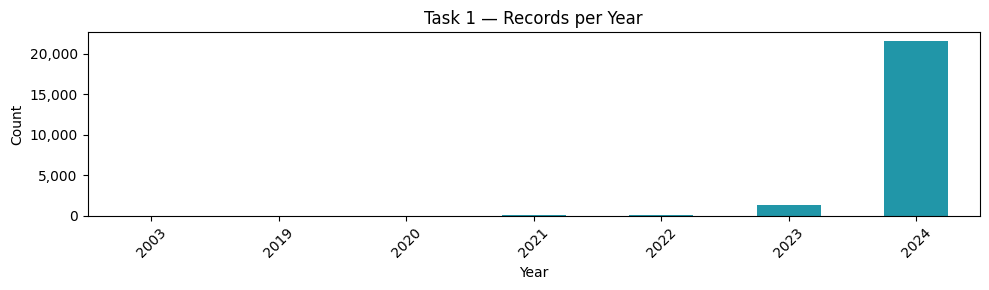

In [11]:
# Records per year
fig, ax = plt.subplots(figsize=(10, 3))
df['AsOfDate'].dt.year.value_counts().sort_index().plot(kind='bar', ax=ax, color='#2196a8')
ax.set_title(f'Task {TASK} — Records per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Label Cleaning

In [12]:
null_labels = df[LABEL_COL].isna().sum()
print(f'Null labels before drop: {null_labels}')
df = df.dropna(subset=[LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

n_classes = df[LABEL_COL].nunique()
print(f'Unique classes found : {n_classes} (expected ~{N_EXPECTED})')

Null labels before drop: 0
Unique classes found : 145 (expected ~145)


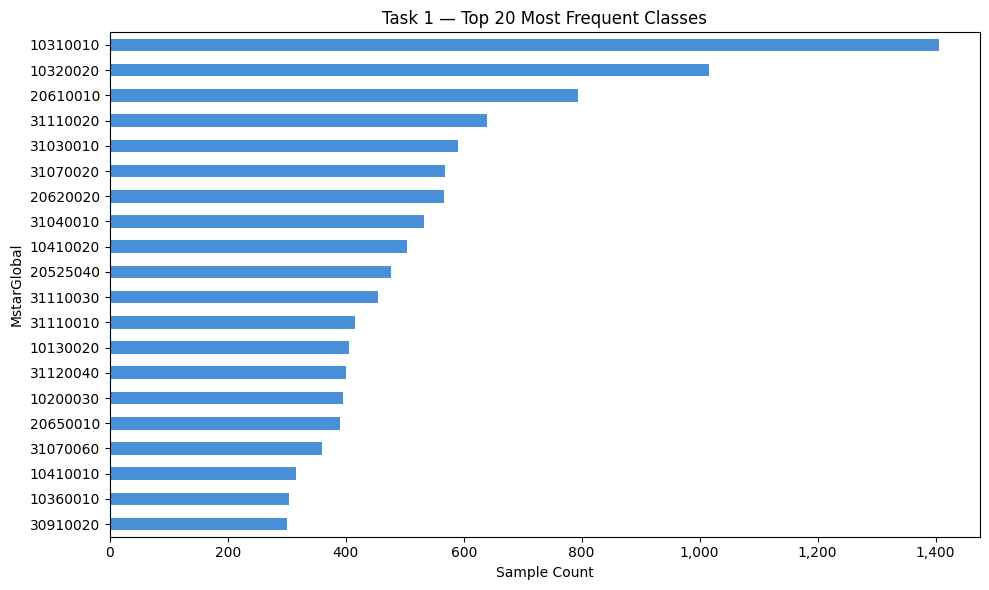

In [13]:
class_counts = df[LABEL_COL].value_counts()

# Top 20 classes
fig, ax = plt.subplots(figsize=(10, 6))
class_counts.head(20).sort_values().plot(kind='barh', ax=ax, color='#4a90d9')
ax.set_title(f'Task {TASK} — Top 20 Most Frequent Classes')
ax.set_xlabel('Sample Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

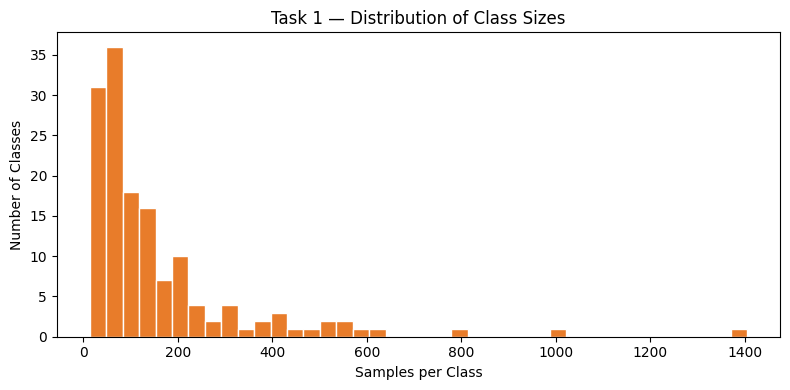


Classes with < 5 samples: 0


In [14]:
# Class imbalance distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(class_counts.values, bins=40, color='#e87c2a', edgecolor='white')
ax.set_title(f'Task {TASK} — Distribution of Class Sizes')
ax.set_xlabel('Samples per Class')
ax.set_ylabel('Number of Classes')
plt.tight_layout()
plt.show()

rare_classes = class_counts[class_counts < 5]
print(f'\nClasses with < 5 samples: {len(rare_classes)}')
if len(rare_classes):
    print(rare_classes.to_string())

## 7. Text Cleaning

In [15]:
PLACEHOLDER_RE = re.compile(
    r'^(nan|none|n/a|na|-|\.|the company)$',
    flags=re.IGNORECASE
)

def clean_text(series: pd.Series, name: str) -> pd.Series:
    series = series.dropna()  # Remove NaN values first
    series = series.astype(str).str.strip()
    series = series.str.replace(r'\s+', ' ', regex=True)           # collapse whitespace
    series = series.str.replace(r'[^\x00-\x7F]+', ' ', regex=True) # remove non-ASCII
    # series = series.str.lower()  # ← uncomment for TF-IDF baseline; leave off for transformers
    series = series.apply(
        lambda x: np.nan if PLACEHOLDER_RE.fullmatch(x.strip()) else x
    )
    null_pct = series.isna().mean() * 100
    print(f'{name:<35} → null after clean: {null_pct:.2f}%')
    return series

text_cols = ['SegmentName', 'SegmentDescription']
if TASK == 1:
    text_cols.insert(0, 'LongProfile')

for col in text_cols:
    df[col] = clean_text(df[col], col)

LongProfile                         → null after clean: 0.00%
SegmentName                         → null after clean: 0.00%
SegmentDescription                  → null after clean: 0.00%


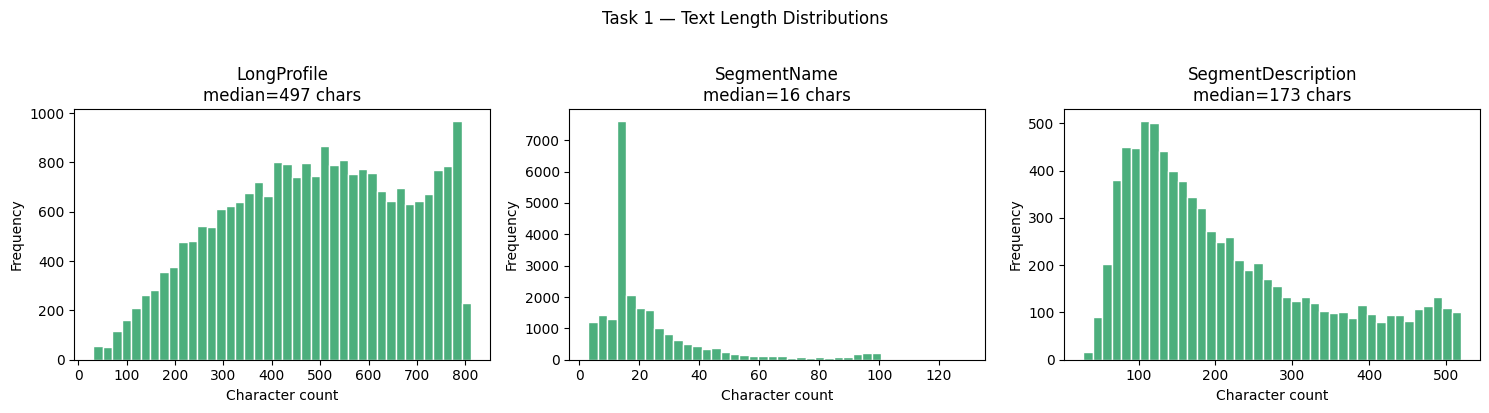

In [16]:
# Text length distribution
fig, axes = plt.subplots(1, len(text_cols), figsize=(5 * len(text_cols), 4))
if len(text_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, text_cols):
    lengths = df[col].dropna().str.len()
    ax.hist(lengths, bins=40, color='#4caf7d', edgecolor='white')
    ax.set_title(f'{col}\nmedian={lengths.median():.0f} chars')
    ax.set_xlabel('Character count')
    ax.set_ylabel('Frequency')

plt.suptitle(f'Task {TASK} — Text Length Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 8. Numeric Cleaning (Task 1 only)

In [17]:
if TASK == 1:
    for col in ['Revenue', 'total_revenue_company_as_of']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        neg = (df[col] < 0).sum()
        if neg:
            print(f' {col}: {neg} negative values → setting to NaN')
            df.loc[df[col] < 0, col] = np.nan

    df['revenue_share'] = pd.to_numeric(df['revenue_share'], errors='coerce')
    bad = ((df['revenue_share'] < 0) | (df['revenue_share'] > 1)).sum()
    if bad:
        print(f'  revenue_share: {bad} values outside [0,1] → setting to NaN')
        df.loc[(df['revenue_share'] < 0) | (df['revenue_share'] > 1), 'revenue_share'] = np.nan

    df['is_largest_share_segment'] = (
        df['is_largest_share_segment'].astype(str).str.strip().str.lower()
        .map({'true': True, 'false': False, '1': True, '0': False, 'yes': True, 'no': False})
    )

    print('\nNumeric summary:')
    display(df[['Revenue', 'total_revenue_company_as_of', 'revenue_share']].describe())
else:
    print('Task 2 — no numeric columns to clean.')

 Revenue: 164 negative values → setting to NaN
 total_revenue_company_as_of: 124 negative values → setting to NaN
  revenue_share: 65 values outside [0,1] → setting to NaN

Numeric summary:


,Revenue,total_revenue_company_as_of,revenue_share
count,2.304300e+04,2.308300e+04,23142.000000
mean,7.831645e+13,1.621125e+14,0.646560
std,1.183381e+16,2.449803e+16,0.391983
min,0.000000e+00,0.000000e+00,0.000000
25%,5.864744e+07,1.527945e+08,0.233437
50%,6.466810e+08,1.701322e+09,0.875136
75%,6.329158e+09,1.594012e+10,1.000000
max,1.796362e+18,3.722006e+18,1.000000


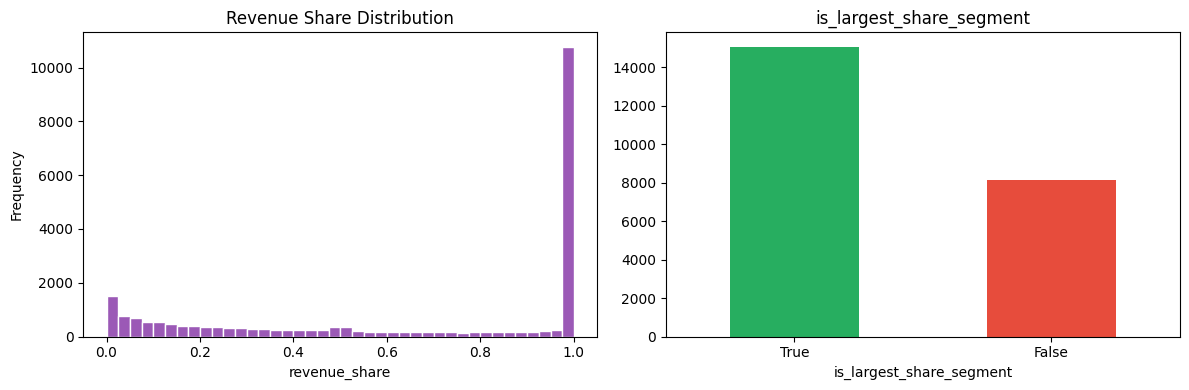

In [18]:
if TASK == 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df['revenue_share'].dropna().plot(
        kind='hist', bins=40, ax=axes[0], color='#9b59b6', edgecolor='white'
    )
    axes[0].set_title('Revenue Share Distribution')
    axes[0].set_xlabel('revenue_share')

    df['is_largest_share_segment'].value_counts().plot(
        kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c']
    )
    axes[1].set_title('is_largest_share_segment')
    axes[1].set_xticklabels(['True', 'False'], rotation=0)
    plt.tight_layout()
    plt.show()

## 9. Drop Rows with Critical Nulls

In [19]:
before = len(df)

if TASK == 1:
    has_profile = df['LongProfile'].notna()
    has_segment = df['SegmentName'].notna() & df['SegmentDescription'].notna()
    mask = has_profile | has_segment
else:
    mask = df['SegmentDescription'].notna()

df = df[mask]
dropped = before - len(df)
print(f'Dropped {dropped:,} rows with insufficient text input.')
print(f'Rows remaining: {len(df):,}')

Dropped 0 rows with insufficient text input.
Rows remaining: 23,207


## 10. Final Null Audit

In [20]:
final_nulls = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct':   (df.isna().mean() * 100).round(2)
}).sort_values('null_pct', ascending=False)

print(final_nulls.to_string())

                             null_count  null_pct
SegmentDescription                14987     64.58
Revenue                             164      0.71
total_revenue_company_as_of         124      0.53
revenue_share                        65      0.28
CompanyId                             0      0.00
AsOfDate                              0      0.00
LongProfile                           0      0.00
SegmentName                           0      0.00
is_largest_share_segment              0      0.00
MstarGlobal                           0      0.00


## 11. Cleaning Summary

In [21]:
class_counts = df[LABEL_COL].value_counts()

print('=' * 55)
print(f'  CLEANING SUMMARY — Task {TASK}')
print('=' * 55)
print(f'  Raw rows            : {len(df_raw):,}')
print(f'  Final rows          : {len(df):,}')
print(f'  Rows removed        : {len(df_raw) - len(df):,} ({(1 - len(df)/len(df_raw))*100:.1f}%)')
print(f'  Unique classes      : {df[LABEL_COL].nunique()}')
print(f'  Most common class   : {class_counts.index[0]} ({class_counts.iloc[0]:,} samples)')
print(f'  Least common class  : {class_counts.index[-1]} ({class_counts.iloc[-1]:,} samples)')
print(f'  Imbalance ratio     : {class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x')
print('=' * 55)

  CLEANING SUMMARY — Task 1
  Raw rows            : 53,585
  Final rows          : 23,207
  Rows removed        : 30,378 (56.7%)
  Unique classes      : 145
  Most common class   : 10310010 (1,405 samples)
  Least common class  : 10340030 (14 samples)
  Imbalance ratio     : 100.4x


## 12. Save Cleaned Data

In [22]:
df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f' Cleaned data saved to: {OUTPUT_PATH}')
print(f'   Shape: {df.shape}')

 Cleaned data saved to: task1_gecs_classification_final_cleaned.csv
   Shape: (23207, 10)
